In [20]:
import torch
import matplotlib.pyplot as plt
from models import ClsModel
from plot_utils import normalize_min_max

In [2]:
checkpoint_path = "weights/cls_model_0.95.pt"

In [16]:
model = ClsModel()
model.load_state_dict(torch.load(checkpoint_path, weights_only=True))

<All keys matched successfully>

In [24]:
model

ClsModel(
  (fc): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=2352, out_features=512, bias=True)
    (2): Tanh()
    (3): Linear(in_features=512, out_features=64, bias=True)
    (4): Tanh()
    (5): Linear(in_features=64, out_features=8, bias=True)
    (6): Tanh()
    (7): Linear(in_features=8, out_features=10, bias=True)
  )
)

In [56]:
weights1 = model.fc[1].weight
weights2 = model.fc[3].weight
weights3 = model.fc[5].weight

Neuron: 0


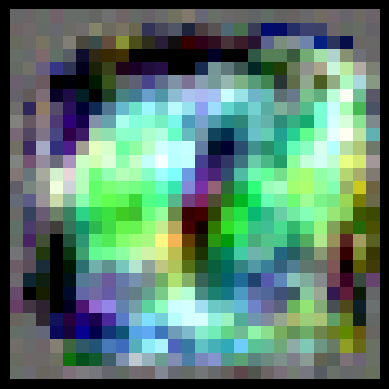

Neuron: 1


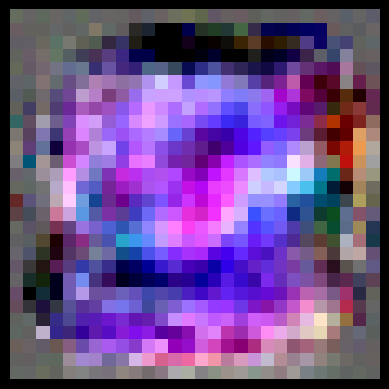

Neuron: 2


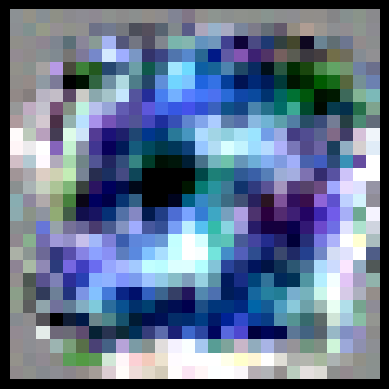

Neuron: 3


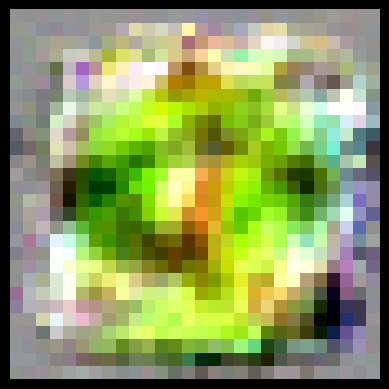

Neuron: 4


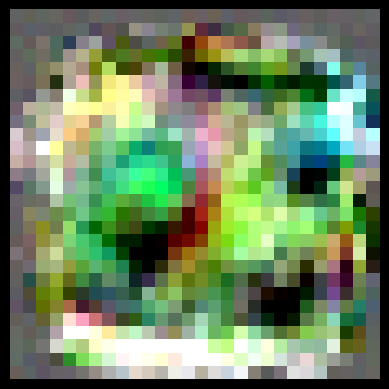

Neuron: 5


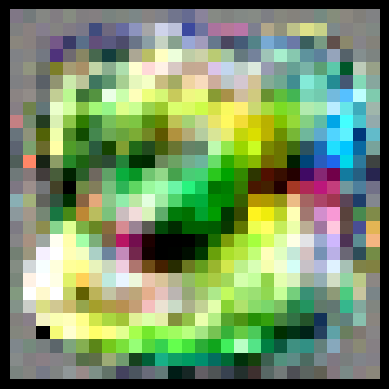

Neuron: 6


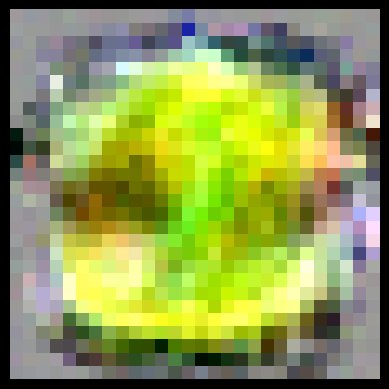

Neuron: 7


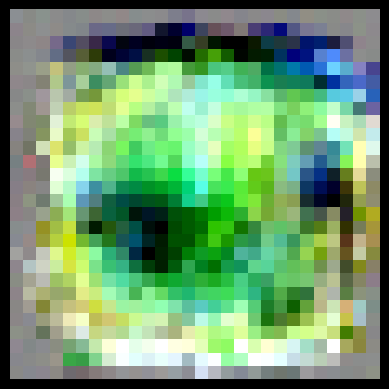

Neuron: 8


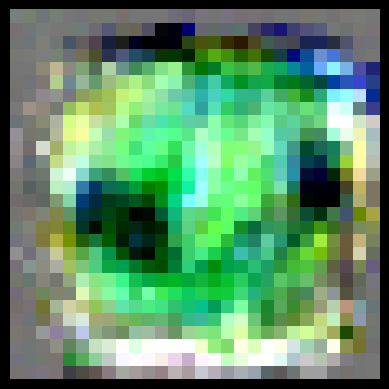

Neuron: 9


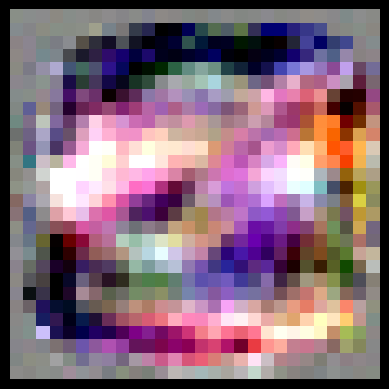

Neuron: 10


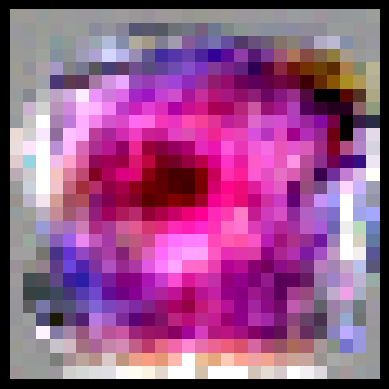

Neuron: 11


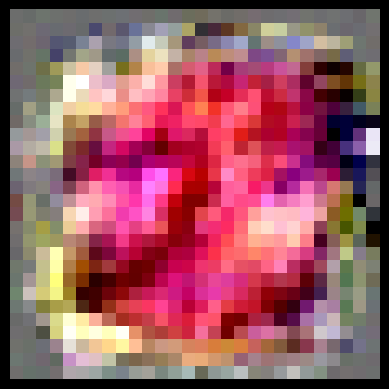

Neuron: 12


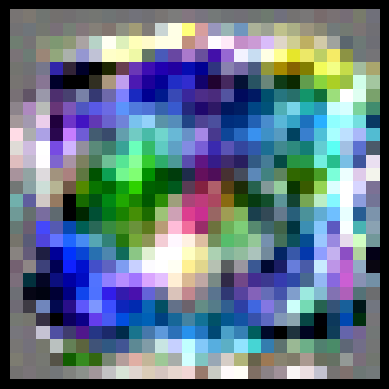

Neuron: 13


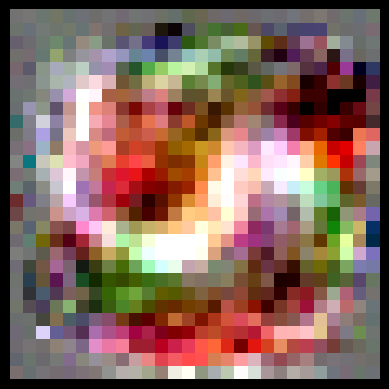

Neuron: 14


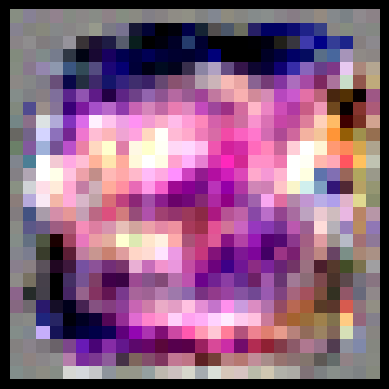

Neuron: 15


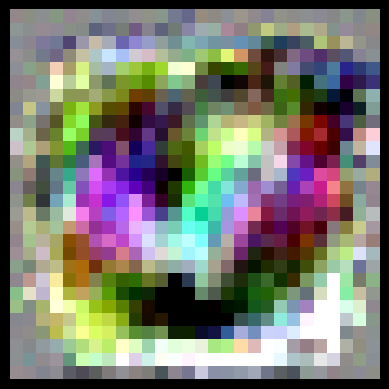

Neuron: 16


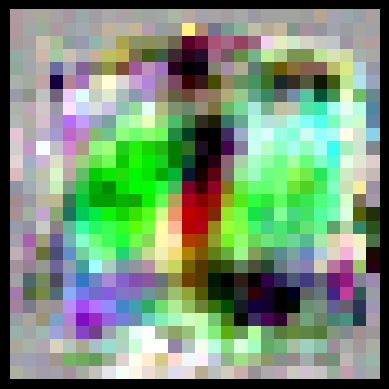

Neuron: 17


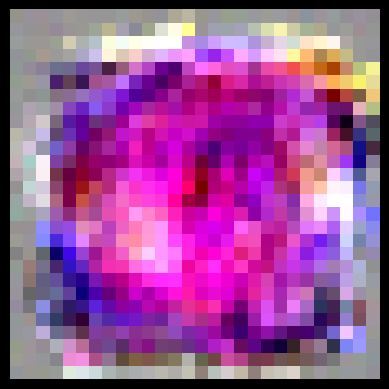

Neuron: 18


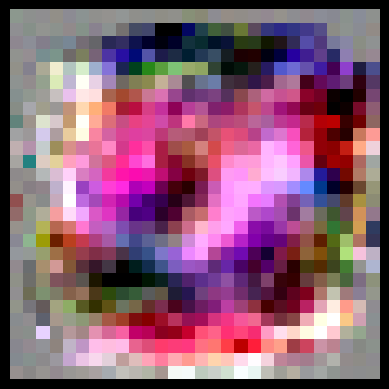

Neuron: 19


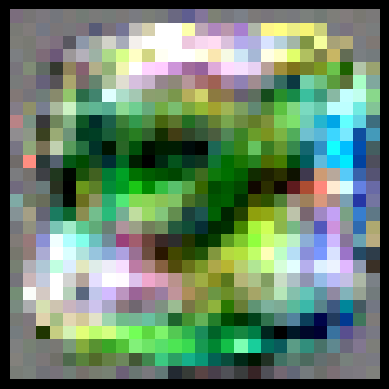

Neuron: 20


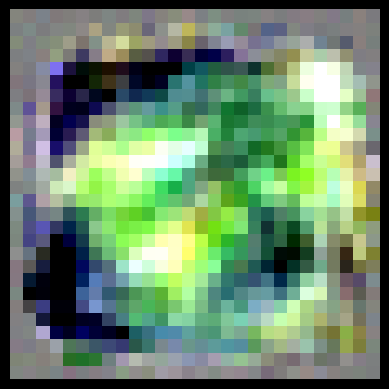

Neuron: 21


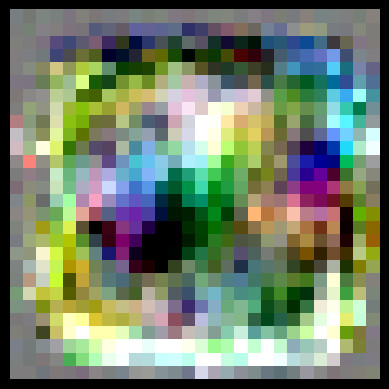

Neuron: 22


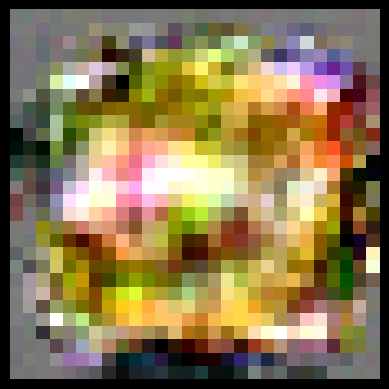

Neuron: 23


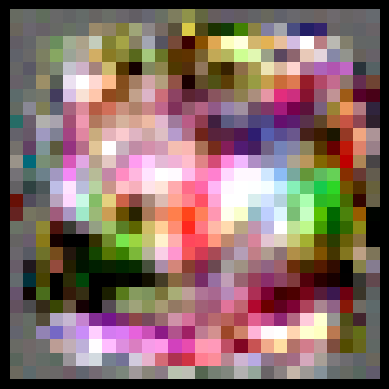

Neuron: 24


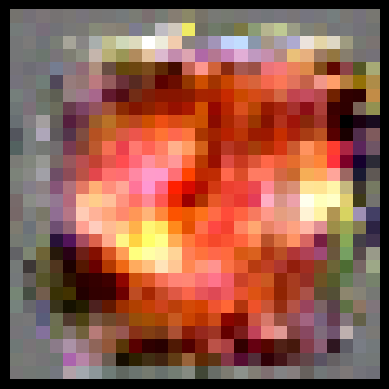

Neuron: 25


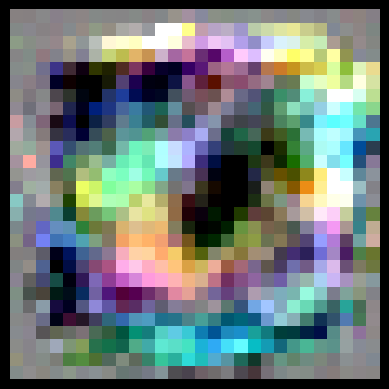

Neuron: 26


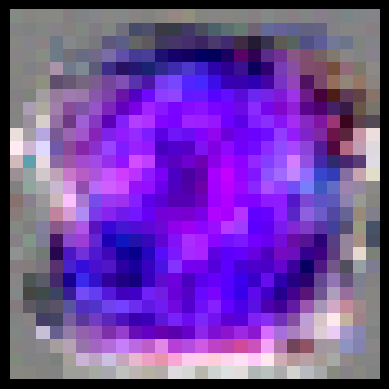

Neuron: 27


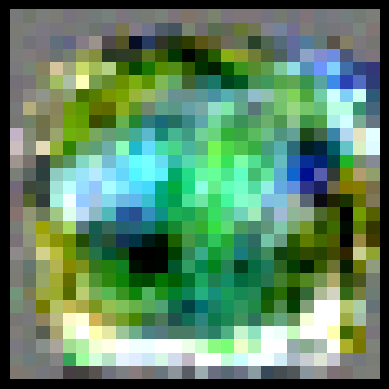

Neuron: 28


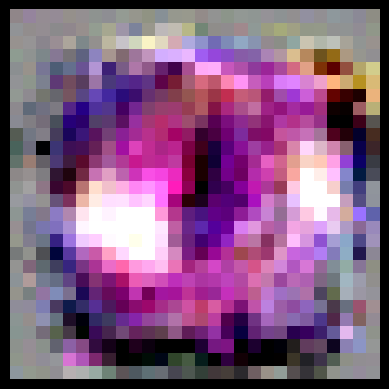

Neuron: 29


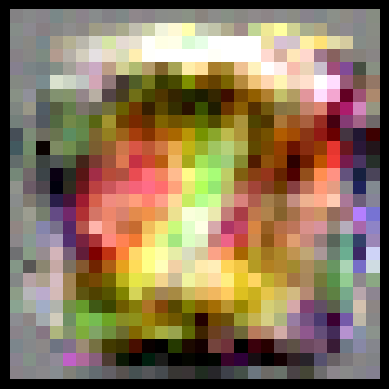

Neuron: 30


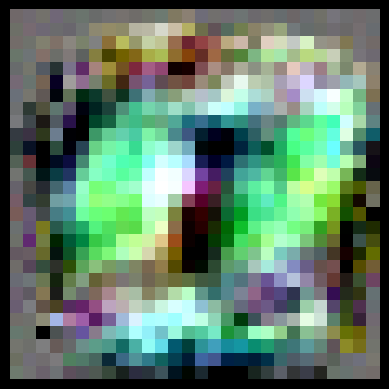

Neuron: 31


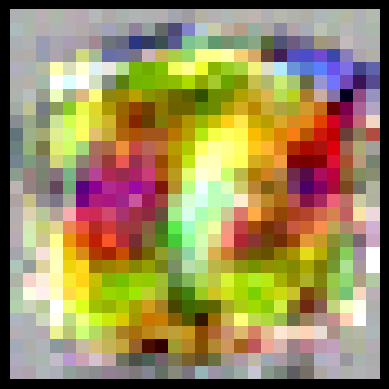

Neuron: 32


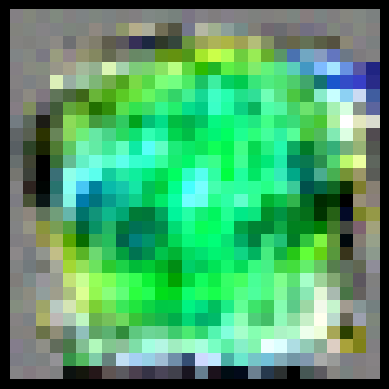

Neuron: 33


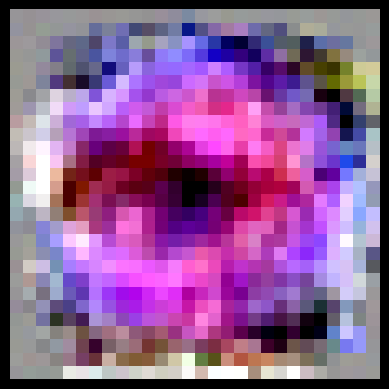

Neuron: 34


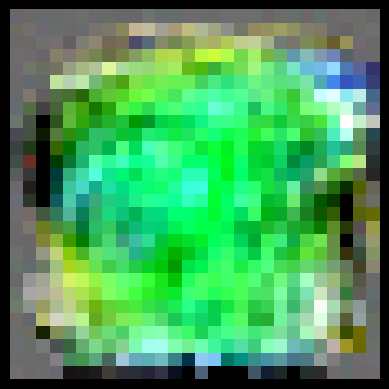

Neuron: 35


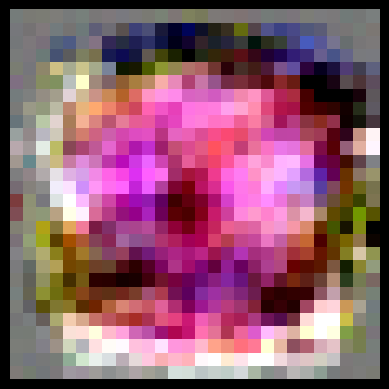

Neuron: 36


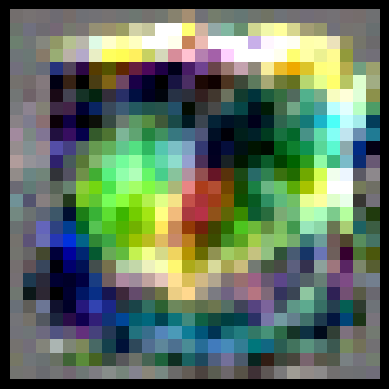

Neuron: 37


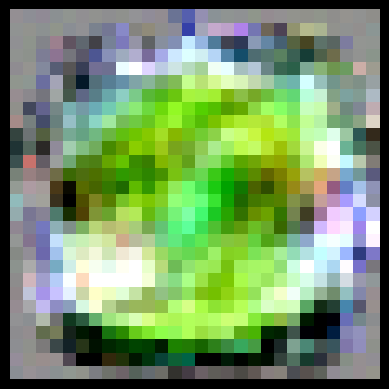

Neuron: 38


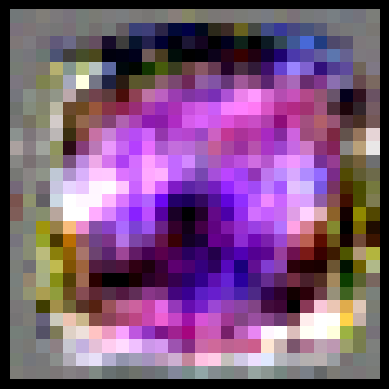

Neuron: 39


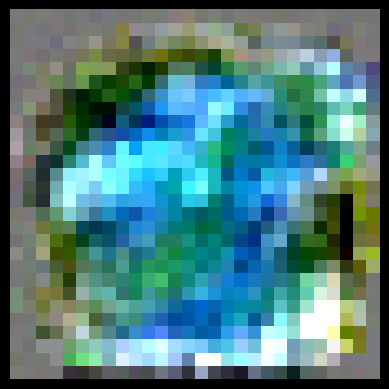

Neuron: 40


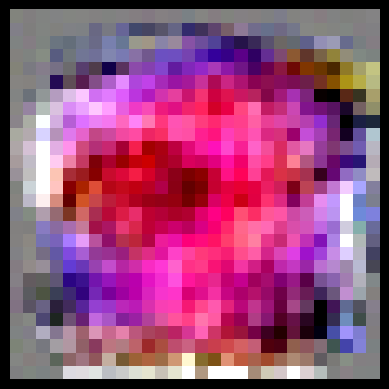

Neuron: 41


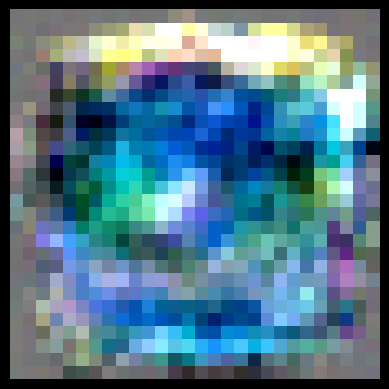

Neuron: 42


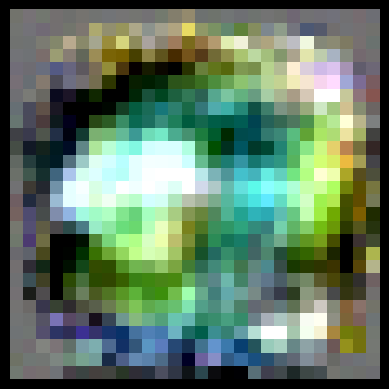

Neuron: 43


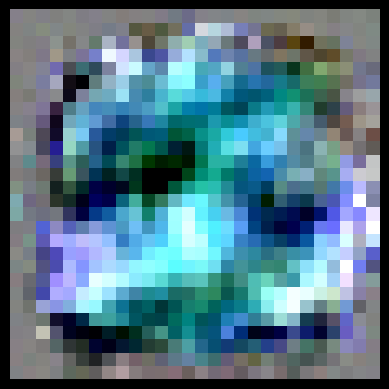

Neuron: 44


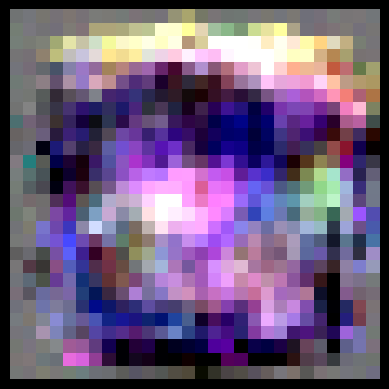

Neuron: 45


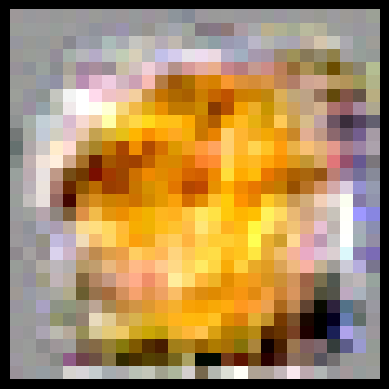

Neuron: 46


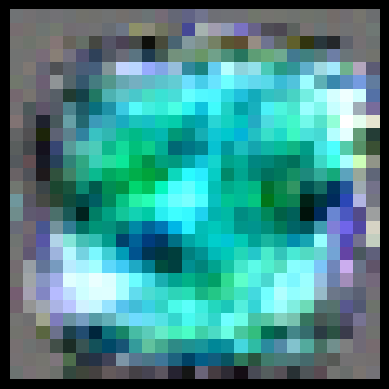

Neuron: 47


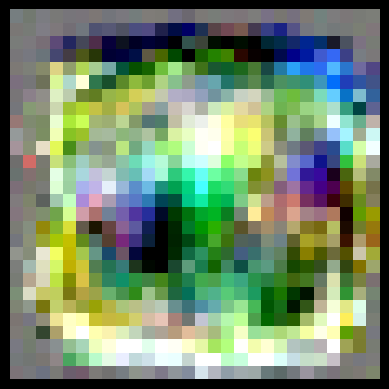

Neuron: 48


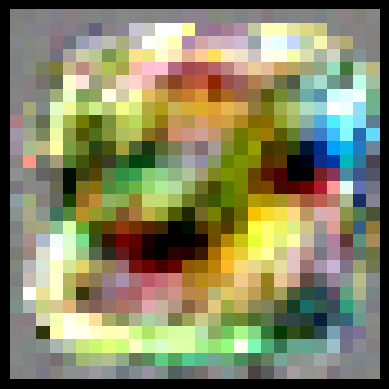

Neuron: 49


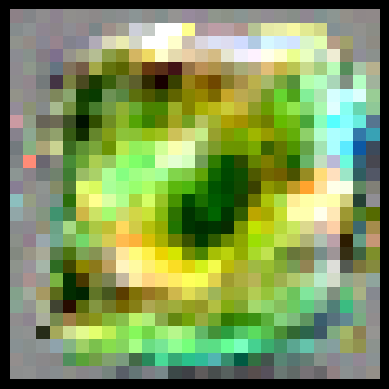

Neuron: 50


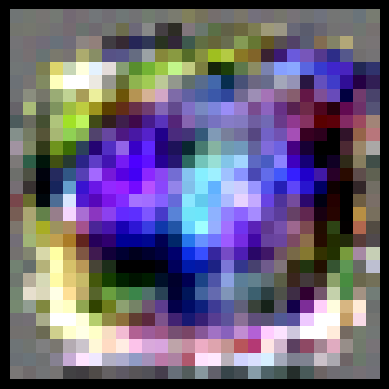

Neuron: 51


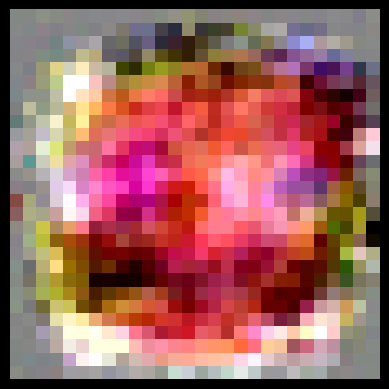

Neuron: 52


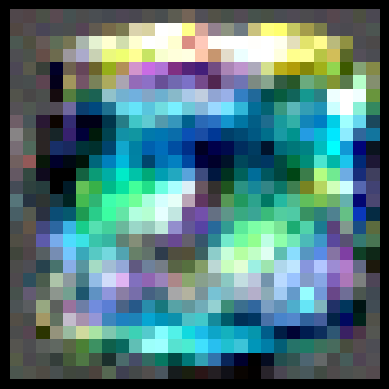

Neuron: 53


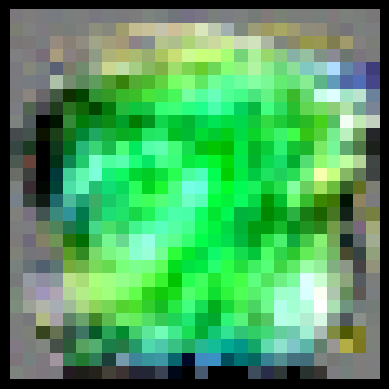

Neuron: 54


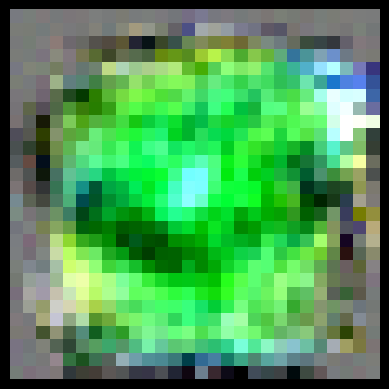

Neuron: 55


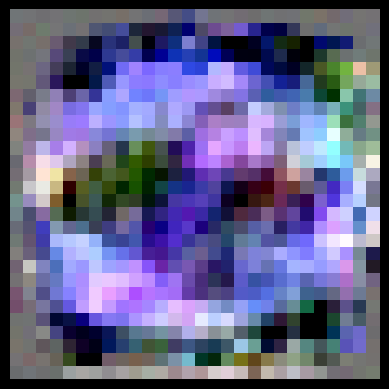

Neuron: 56


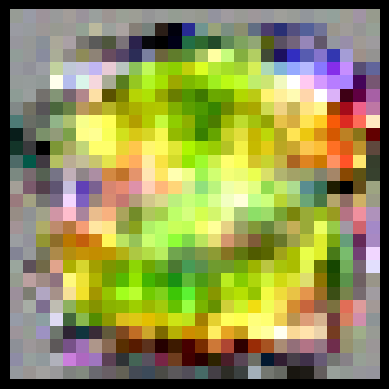

Neuron: 57


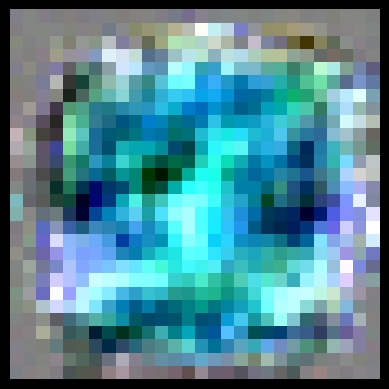

Neuron: 58


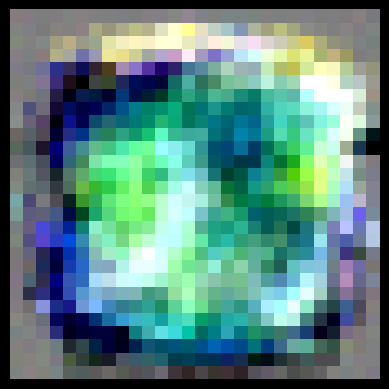

Neuron: 59


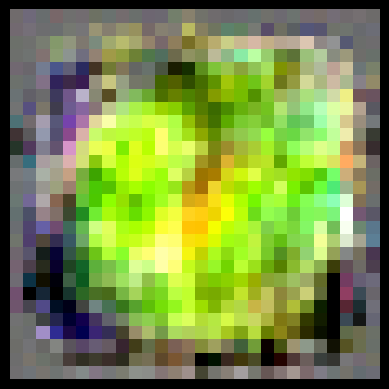

Neuron: 60


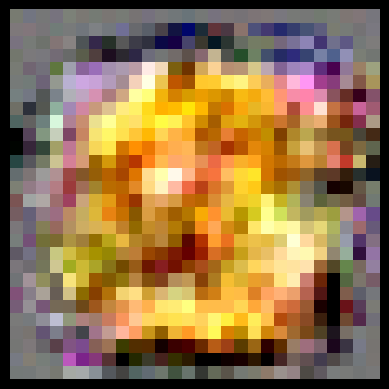

Neuron: 61


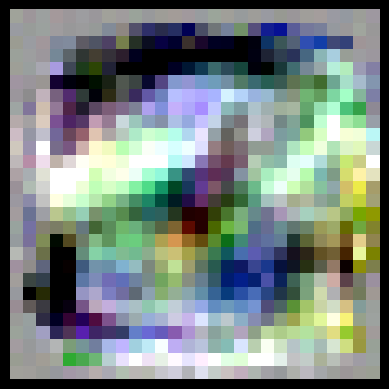

Neuron: 62


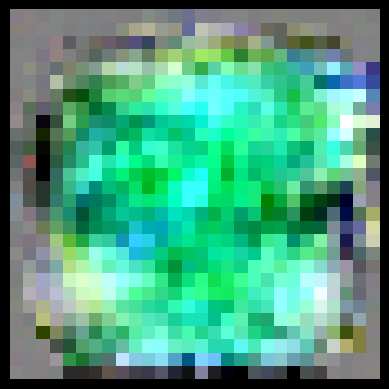

Neuron: 63


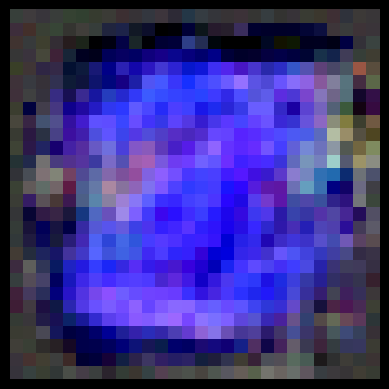

In [60]:
for i in range(64):
	# act = ((weights3[i].unsqueeze(1)*weights2).sum(0).unsqueeze(1)*torch.relu(weights1)).sum(dim=0).reshape(3, 28, 28).permute(1, 2, 0)
	act = (weights2[i].unsqueeze(1)*torch.relu(weights1)).sum(dim=0).reshape(3, 28, 28).permute(1, 2, 0)
	# act = model.fc[1].weight[i].reshape(3, 28, 28).permute(1, 2, 0)
	min_value = torch.quantile(act, q=0.05)
	max_value = torch.quantile(act, q=0.95)
	act = torch.clip(act, min_value, max_value)
	print(f"Neuron: {i}")
	plt.imshow(normalize_min_max(act.detach()))
	plt.axis("off")
	plt.show()

In [61]:
train_dataset = torch.load("./data/train_dataset.pt", weights_only=False)

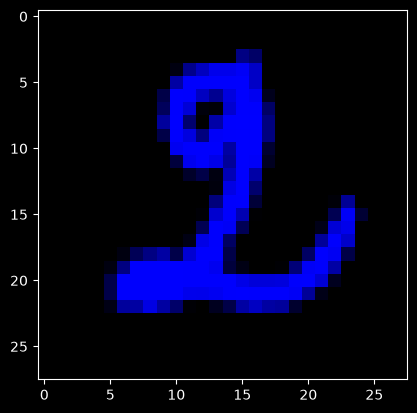

In [108]:
example_input = train_dataset[41][0]
plt.imshow(example_input.permute(1, 2, 0))

In [114]:
model.fc[:2](example_input.unsqueeze(0)).topk(50).indices.sort()

torch.return_types.sort(
values=tensor([[  2,  39,  42,  52,  55,  59,  64,  75,  78,  85,  88,  91, 111, 114,
         115, 119, 131, 163, 170, 181, 183, 189, 205, 236, 241, 242, 243, 252,
         267, 287, 299, 310, 317, 334, 335, 351, 354, 368, 404, 418, 421, 434,
         455, 457, 460, 466, 468, 469, 505, 509]]),
indices=tensor([[32,  3, 26,  1, 29, 12, 22, 42, 34, 43,  9, 14, 17, 18, 24,  5, 39, 19,
         11, 23, 36, 45, 28,  6, 25, 40, 44, 37, 30, 38, 31, 13, 46,  8, 33, 49,
         35, 15, 10,  0,  2, 27, 41, 48,  7, 20, 16, 21,  4, 47]]))